In [1]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Tree overlap

In [58]:
try:
    # 1. 运行 C++ 程序并捕获输出
    executable = "../anchor_mapping"
    args = [
        "--max_node_capacity", "10",
        "--leaf_radius_threshold", "0",
        "--compactness_min_capacity", "1000",
        "--compactness_radius_factor", "1000"
    ]
    command = [executable] + args

    result = subprocess.run(
        command,  # 正确地传入分解后的列表
        capture_output=True,
        text=True,
        check=True
    )
    output = result.stdout
    
except FileNotFoundError:
    print(f"错误: 找不到可执行文件。请确保文件路径正确且已编译。")
except subprocess.CalledProcessError as e:
    print(f"错误: C++ 程序运行失败，退出码 {e.returncode}。")
    print("--- C++ 错误输出 ---")
    print(e.stderr)

# 2. 解析 C++ 输出中的数据
parsed_data = {} # 结构: {layer: {'total': N, 'multi_contained': M, 'total_overlap': T}}

# 正则表达式用于匹配新的输出格式
# 匹配 父层级: (N) | 子节点总数: (N) | 被多次覆盖枢轴数: (N) (...) | 总重叠次数: (N)
pattern = re.compile(
    r"父层级:\s+(\d+)\s+\|\s+子节点总数:\s+(\d+)\s+\|\s+被多次覆盖枢轴数:\s+(\d+)\s+.*?\s+\|\s+总重叠次数:\s+(\d+)"
)

for line in output.splitlines():
    match = pattern.search(line)
    if match:
        layer = int(match.group(1))
        total_nodes = int(match.group(2))
        multi_contained = int(match.group(3))
        total_overlap = int(match.group(4))
        
        parsed_data[layer] = {
            'total': total_nodes,
            'multi_contained': multi_contained,
            'total_overlap': total_overlap
        }

if not parsed_data:
    print("警告: 未能在 C++ 输出中找到重叠度数据。请检查 C++ 输出格式是否符合预期。")
    print("--- C++ 原始输出 ---")
    print(output)


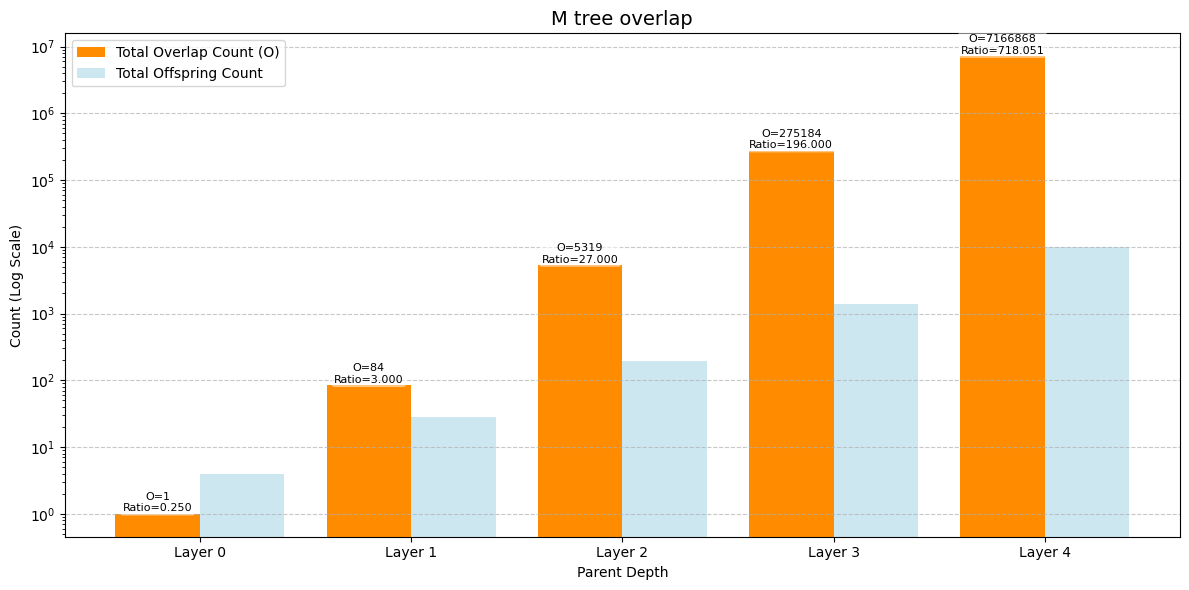

In [59]:
# 3. 准备绘图数据
layers = sorted(parsed_data.keys())
# 绘制总重叠次数
total_overlap_counts = [parsed_data[l]['total_overlap'] for l in layers]
total_nodes_counts = [parsed_data[l]['total'] for l in layers]
T_plot_values = np.clip(total_overlap_counts, a_min=1, a_max=None) # 用于绘图
layer_labels = [f'Layer {l}' for l in layers]
x = np.arange(len(layer_labels)) # x 轴标签位置
layer_labels = [f'Layer {l}' for l in layers]
x = np.arange(len(layer_labels))  # x 轴标签位置
bar_width = 0.4 # 柱子宽度

# 4. 绘制单图表 (无 Subplot)
plt.figure(figsize=(12, 6))
ax = plt.gca() # 获取当前的 Axes 对象

# --- 绘制总重叠次数 (T) ---
# 注意：使用 total_overlap_counts 对应您的 bars1
bars1 = ax.bar(x - bar_width/2, T_plot_values, bar_width, label='Total Overlap Count (O)', color='darkorange')

# --- 绘制总子节点数 (Total) 作为参考柱 ---
bars2 = ax.bar(x + bar_width/2, total_nodes_counts, bar_width, label='Total Offspring Count', color='lightblue', alpha=0.6)

# --- 设置 Y 轴为对数刻度 ---
ax.set_yscale('log')
ax.set_title('M tree overlap', fontsize=14)
ax.set_xlabel('Parent Depth')
ax.set_ylabel('Count (Log Scale)')
ax.set_xticks(x)
ax.set_xticklabels(layer_labels)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# 5. 添加数值标签和比值
for i, bar in enumerate(bars1):
    yval = bar.get_height()
    total_node_count = total_nodes_counts[i]
    
    # 避免除以零
    overlap_ratio = yval / total_node_count if total_node_count > 0 else 0.0
    
    # 显示总重叠次数和比值
    label_text = f'O={int(yval)}\nRatio={overlap_ratio:.3f}'
    
    # 在柱子上方放置标签
    # 由于是 log 刻度，需要稍微调整 y 位置
    ax.text(bar.get_x() + bar.get_width()/2, yval*1.02, label_text, 
            ha='center', va='bottom', fontsize=8, color='black', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round, pad=0.2')) 

plt.tight_layout()
plt.show()

In [3]:
try:
    # 1. 运行 C++ 程序并捕获输出
    # 1. 运行 C++ 程序并捕获输出
    executable = "../anchor_mapping"
    args = [
        "--max_node_capacity", "10",
        "--leaf_radius_threshold", "6",
        "--compactness_min_capacity", "8",
        "--compactness_radius_factor", "1.1"
    ]
    command = [executable] + args

    result = subprocess.run(
        command,  # 正确地传入分解后的列表
        capture_output=True,
        text=True,
        check=True
    )
    output = result.stdout
    
except FileNotFoundError:
    print(f"错误: 找不到可执行文件。请确保文件路径正确且已编译。")
except subprocess.CalledProcessError as e:
    print(f"错误: C++ 程序运行失败，退出码 {e.returncode}。")
    print("--- C++ 错误输出 ---")
    print(e.stderr)

# 2. 解析 C++ 输出中的数据
parsed_data = {} # 结构: {layer: {'total': N, 'multi_contained': M, 'total_overlap': T}}

# 正则表达式用于匹配新的输出格式
# 匹配 父层级: (N) | 子节点总数: (N) | 被多次覆盖枢轴数: (N) (...) | 总重叠次数: (N)
pattern = re.compile(
    r"父层级:\s+(\d+)\s+\|\s+子节点总数:\s+(\d+)\s+\|\s+被多次覆盖枢轴数:\s+(\d+)\s+.*?\s+\|\s+总重叠次数:\s+(\d+)"
)

for line in output.splitlines():
    match = pattern.search(line)
    if match:
        layer = int(match.group(1))
        total_nodes = int(match.group(2))
        multi_contained = int(match.group(3))
        total_overlap = int(match.group(4))
        
        parsed_data[layer] = {
            'total': total_nodes,
            'multi_contained': multi_contained,
            'total_overlap': total_overlap
        }

if not parsed_data:
    print("警告: 未能在 C++ 输出中找到重叠度数据。请检查 C++ 输出格式是否符合预期。")
    print("--- C++ 原始输出 ---")
    print(output)


警告: 未能在 C++ 输出中找到重叠度数据。请检查 C++ 输出格式是否符合预期。
--- C++ 原始输出 ---
fasta_path: /home/luting/nfs/luting_data/AnchorBasedMapping/ecoli/fasta/ecoli.fa
truncate_ref_len: 10000
anchor_len: 20
num_anchors: 100
num_queries: 100
maxDist: 3
use_all: true
start_idx: 0
end_idx: 0.2
last_random: 0
anchor radius: 3
seed: 42
--- M-Tree Config ---
min_node_capacity: 50
max_node_capacity: 10
leaf_radius_threshold: 6
compactness_min_capacity: 8
compactness_radius_factor: 1.1
auto generate queries: 0
Using reference (truncated) length = 10000
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node compact!
non leaf node compact!
leaf node comp

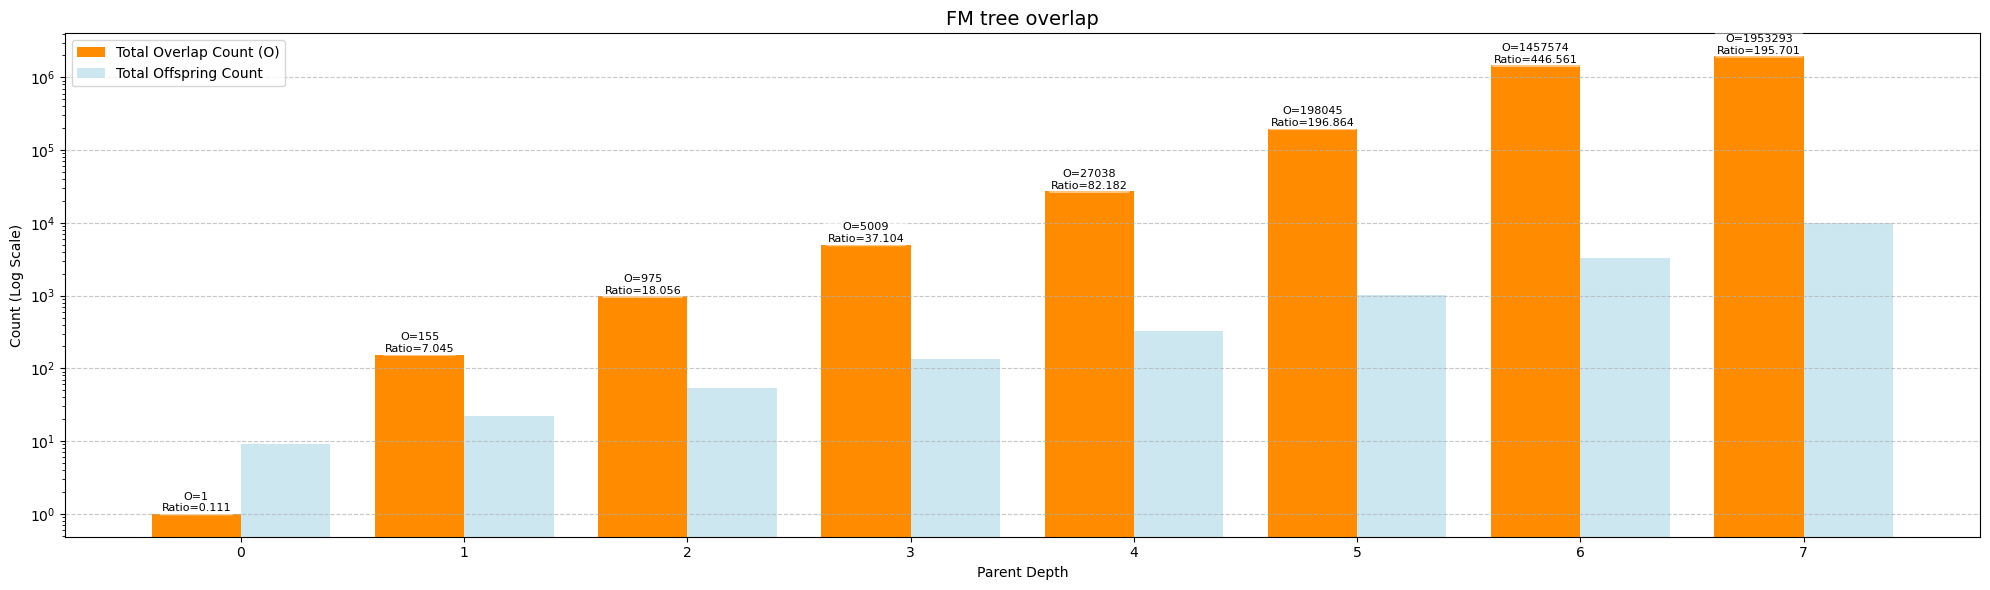

In [61]:
# 3. 准备绘图数据
layers = sorted(parsed_data.keys())
# 绘制总重叠次数
total_overlap_counts = [parsed_data[l]['total_overlap'] for l in layers]
total_nodes_counts = [parsed_data[l]['total'] for l in layers]
T_plot_values = np.clip(total_overlap_counts, a_min=1, a_max=None) # 用于绘图
layer_labels = [l for l in layers]
x = np.arange(len(layer_labels)) # x 轴标签位置
layer_labels = [l for l in layers]
x = np.arange(len(layer_labels))  # x 轴标签位置
bar_width = 0.4 # 柱子宽度

# 4. 绘制单图表 (无 Subplot)
plt.figure(figsize=(20, 6))
ax = plt.gca() # 获取当前的 Axes 对象

# --- 绘制总重叠次数 (T) ---
# 注意：使用 total_overlap_counts 对应您的 bars1
bars1 = ax.bar(x - bar_width/2, T_plot_values, bar_width, label='Total Overlap Count (O)', color='darkorange')

# --- 绘制总子节点数 (Total) 作为参考柱 ---
bars2 = ax.bar(x + bar_width/2, total_nodes_counts, bar_width, label='Total Offspring Count', color='lightblue', alpha=0.6)

# --- 设置 Y 轴为对数刻度 ---
ax.set_yscale('log')
ax.set_title('FM tree overlap', fontsize=14)
ax.set_xlabel('Parent Depth')
ax.set_ylabel('Count (Log Scale)')
ax.set_xticks(x)
ax.set_xticklabels(layer_labels)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# 5. 添加数值标签和比值
for i, bar in enumerate(bars1):
    yval = bar.get_height()
    total_node_count = total_nodes_counts[i]
    
    # 避免除以零
    overlap_ratio = yval / total_node_count if total_node_count > 0 else 0.0
    
    # 显示总重叠次数和比值
    label_text = f'O={int(yval)}\nRatio={overlap_ratio:.3f}'
    
    # 在柱子上方放置标签
    # 由于是 log 刻度，需要稍微调整 y 位置
    ax.text(bar.get_x() + bar.get_width()/2, yval*1.02, label_text, 
            ha='center', va='bottom', fontsize=8, color='black', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round, pad=0.2')) 

plt.tight_layout()
plt.show()

# Tree node access

Running command: ../anchor_mapping --min_node_capacity 25 --leaf_radius_threshold 30 --compactness_min_capacity 5 --compactness_radius_factor 1 --auto_gen true --method mtree

--- Node Access Histogram Plotting ---
Collected 199 individual node access data points.
Saved node access histogram to ./fig/histogram_node_accesses_fmtree.png

--- LeafNode Radius Histogram Plotting ---
Collected 11089 individual radius data points.
Saved radius histogram to ./fig/histogram_leafnode_radii_fmtree.png

Displaying plots...


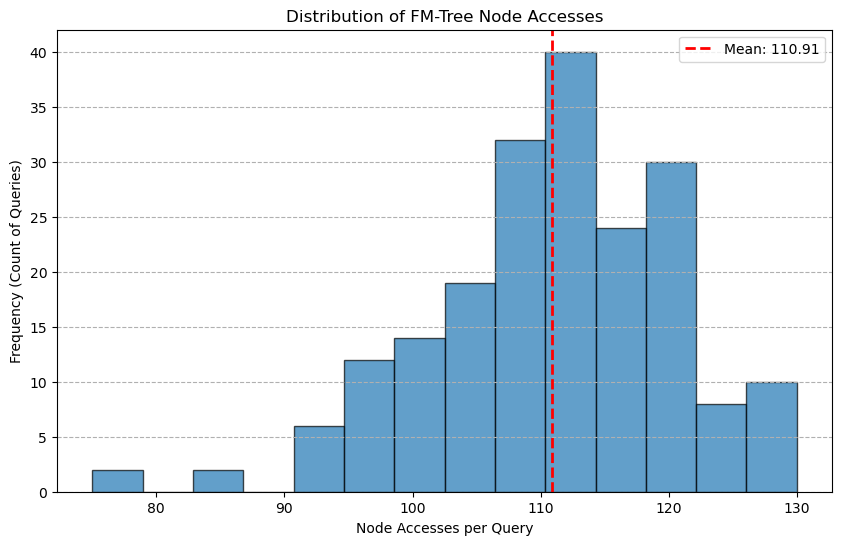

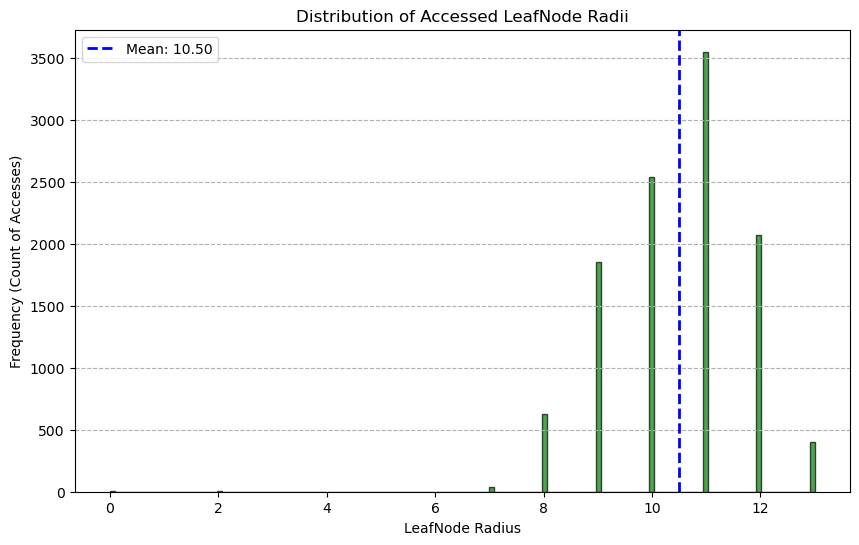

Script finished.


In [7]:
# --- 配置参数 ---
EXECUTABLE = "../anchor_mapping"

# 固定的测试参数 (只运行一次，不进行 sweep)
args = [
        "--min_node_capacity", "25",
        "--leaf_radius_threshold", "30",
        "--compactness_min_capacity", "5",
        "--compactness_radius_factor", "1",
        "--auto_gen", "true",
        "--method", "mtree"
    ]

# --- 运行和数据收集 ---

# 列表用于存储所有查询的单个节点访问次数
all_node_accesses = []
# 新增: 列表用于存储所有被访问的 LeafNode 半径
all_leafnode_radii = []

print(f"Running command: {EXECUTABLE} {' '.join(args)}")

# 构造命令行
cmd = [EXECUTABLE] + args

# 执行程序
proc = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8')

if proc.returncode != 0:
    print(f"Error running command: {' '.join(cmd)}")
    print(f"STDERR:\n{proc.stderr}")
    exit(1)

output = proc.stdout

# 1. 提取所有 "M-Tree search node accesses" 的值
access_pattern = r"M-Tree search node accesses: (\d+)"
accesses_this_run = re.findall(access_pattern, output)

# 将字符串转换为整数并存储
if accesses_this_run:
    all_node_accesses.extend([int(count) for count in accesses_this_run])
else:
    print("⚠️ Warning: No 'FM-Tree search node accesses' output found.")


# 2. 新增: 提取所有 "LeafNode Radius" 的值
#    (假设 C++ 输出格式为 "LeafNode Radius: 12.34")
radius_pattern = r"LeafNode Radius: ([0-9.eE+-]+)"
radii_this_run = re.findall(radius_pattern, output)

# 将字符串转换为浮点数并存储
if radii_this_run:
    all_leafnode_radii.extend([float(r) for r in radii_this_run])
else:
    print("⚠️ Warning: No 'LeafNode Radius' output found.")


# --- 结果可视化：绘制直方图 1 (Node Access) ---

print(f"\n--- Node Access Histogram Plotting ---")
total_data_points = len(all_node_accesses)
print(f"Collected {total_data_points} individual node access data points.")

if total_data_points == 0:
    print("Cannot plot node access histogram as no data was collected.")
else:
    os.makedirs("./fig", exist_ok=True)
    plt.figure(figsize=(10, 6)) # 创建第一个图窗
    
    n, bins, patches = plt.hist(
        all_node_accesses, 
        bins='auto', 
        edgecolor='black', 
        alpha=0.7
    )
    
    plt.title(f"Distribution of FM-Tree Node Accesses")
    plt.xlabel("Node Accesses per Query")
    plt.ylabel("Frequency (Count of Queries)")
    plt.grid(axis='y', linestyle='--')
    
    avg_accesses = sum(all_node_accesses) / total_data_points
    plt.axvline(avg_accesses, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {avg_accesses:.2f}')
    plt.legend()

    filename = f"./fig/histogram_node_accesses_fmtree.png"
    plt.savefig(filename)
    print(f"Saved node access histogram to {filename}")

# --- 新增: 结果可视化：绘制直方图 2 (LeafNode Radius) ---

print(f"\n--- LeafNode Radius Histogram Plotting ---")
total_radius_points = len(all_leafnode_radii)
print(f"Collected {total_radius_points} individual radius data points.")

if total_radius_points == 0:
    print("Cannot plot radius histogram as no data was collected.")
else:
    os.makedirs("./fig", exist_ok=True)
    plt.figure(figsize=(10, 6)) # 创建第二个图窗
    
    plt.hist(
        all_leafnode_radii, 
        bins='auto', 
        edgecolor='black', 
        alpha=0.7,
        color='green' # 换个颜色
    )
    
    plt.title(f"Distribution of Accessed LeafNode Radii")
    plt.xlabel("LeafNode Radius")
    plt.ylabel("Frequency (Count of Accesses)")
    plt.grid(axis='y', linestyle='--')
    
    avg_radius = sum(all_leafnode_radii) / total_radius_points
    plt.axvline(avg_radius, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {avg_radius:.2f}')
    plt.legend()

    filename_radius = f"./fig/histogram_leafnode_radii_fmtree.png"
    plt.savefig(filename_radius)
    print(f"Saved radius histogram to {filename_radius}")

# --- 显示所有图像 ---
print("\nDisplaying plots...")
plt.show()

print("Script finished.")

Running command: ../anchor_mapping --min_node_capacity 25 --leaf_radius_threshold 0 --compactness_min_capacity 1000 --compactness_radius_factor 1000 --auto_gen true --method mtree

--- Node Access Histogram Plotting ---
Collected 198 individual node access data points.
Saved node access histogram to ./fig/histogram_node_accesses_fmtree.png

--- LeafNode Radius Histogram Plotting ---
Collected 28078 individual radius data points.
Saved radius histogram to ./fig/histogram_leafnode_radii_fmtree.png

Displaying plots...


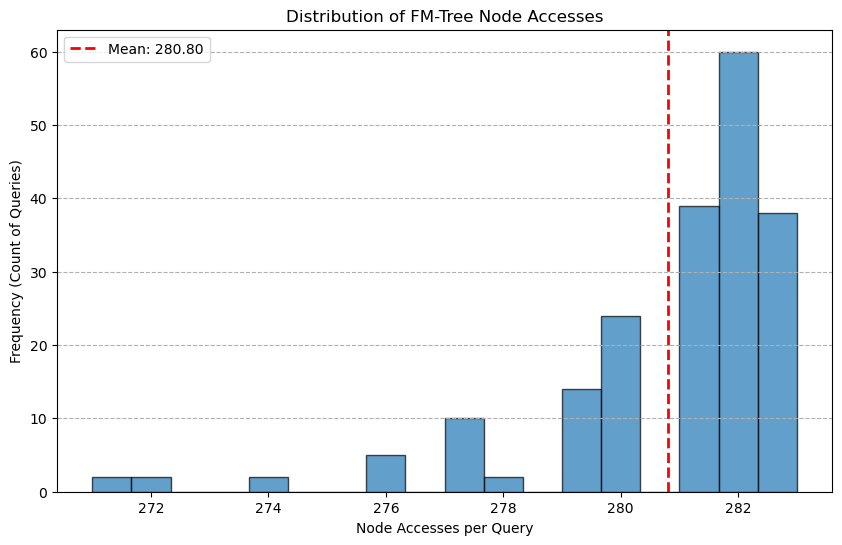

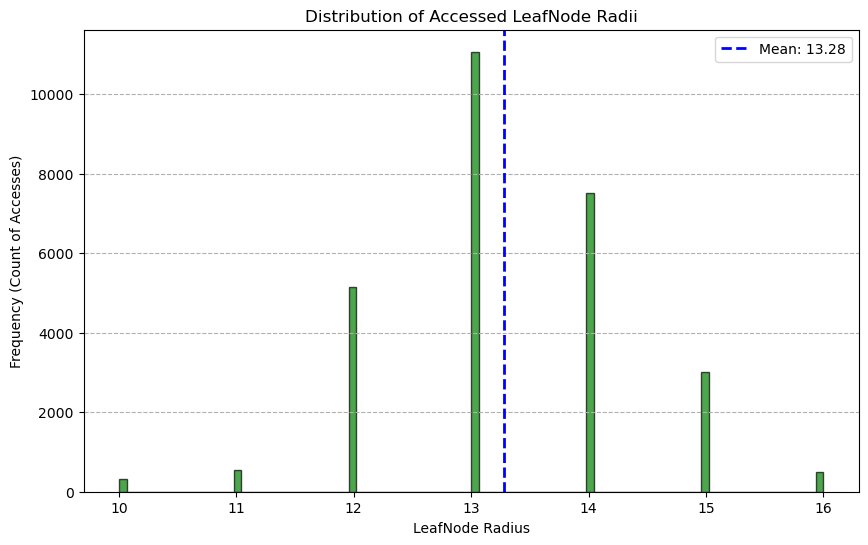

Script finished.


In [5]:
# --- 配置参数 ---
EXECUTABLE = "../anchor_mapping"

# 固定的测试参数 (只运行一次，不进行 sweep)
args = [
        "--min_node_capacity", "25",
        "--leaf_radius_threshold", "0",
        "--compactness_min_capacity", "1000",
        "--compactness_radius_factor", "1000",
        "--auto_gen", "true",
        "--method", "mtree"
    ]

# --- 运行和数据收集 ---

# 列表用于存储所有查询的单个节点访问次数
all_node_accesses = []
# 新增: 列表用于存储所有被访问的 LeafNode 半径
all_leafnode_radii = []

print(f"Running command: {EXECUTABLE} {' '.join(args)}")

# 构造命令行
cmd = [EXECUTABLE] + args

# 执行程序
proc = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8')

if proc.returncode != 0:
    print(f"Error running command: {' '.join(cmd)}")
    print(f"STDERR:\n{proc.stderr}")
    exit(1)

output = proc.stdout

# 1. 提取所有 "M-Tree search node accesses" 的值
access_pattern = r"M-Tree search node accesses: (\d+)"
accesses_this_run = re.findall(access_pattern, output)

# 将字符串转换为整数并存储
if accesses_this_run:
    all_node_accesses.extend([int(count) for count in accesses_this_run])
else:
    print("⚠️ Warning: No 'FM-Tree search node accesses' output found.")


# 2. 新增: 提取所有 "LeafNode Radius" 的值
#    (假设 C++ 输出格式为 "LeafNode Radius: 12.34")
radius_pattern = r"LeafNode Radius: ([0-9.eE+-]+)"
radii_this_run = re.findall(radius_pattern, output)

# 将字符串转换为浮点数并存储
if radii_this_run:
    all_leafnode_radii.extend([float(r) for r in radii_this_run])
else:
    print("⚠️ Warning: No 'LeafNode Radius' output found.")


# --- 结果可视化：绘制直方图 1 (Node Access) ---

print(f"\n--- Node Access Histogram Plotting ---")
total_data_points = len(all_node_accesses)
print(f"Collected {total_data_points} individual node access data points.")

if total_data_points == 0:
    print("Cannot plot node access histogram as no data was collected.")
else:
    os.makedirs("./fig", exist_ok=True)
    plt.figure(figsize=(10, 6)) # 创建第一个图窗
    
    n, bins, patches = plt.hist(
        all_node_accesses, 
        bins='auto', 
        edgecolor='black', 
        alpha=0.7
    )
    
    plt.title(f"Distribution of FM-Tree Node Accesses")
    plt.xlabel("Node Accesses per Query")
    plt.ylabel("Frequency (Count of Queries)")
    plt.grid(axis='y', linestyle='--')
    
    avg_accesses = sum(all_node_accesses) / total_data_points
    plt.axvline(avg_accesses, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {avg_accesses:.2f}')
    plt.legend()

    filename = f"./fig/histogram_node_accesses_fmtree.png"
    plt.savefig(filename)
    print(f"Saved node access histogram to {filename}")

# --- 新增: 结果可视化：绘制直方图 2 (LeafNode Radius) ---

print(f"\n--- LeafNode Radius Histogram Plotting ---")
total_radius_points = len(all_leafnode_radii)
print(f"Collected {total_radius_points} individual radius data points.")

if total_radius_points == 0:
    print("Cannot plot radius histogram as no data was collected.")
else:
    os.makedirs("./fig", exist_ok=True)
    plt.figure(figsize=(10, 6)) # 创建第二个图窗
    
    plt.hist(
        all_leafnode_radii, 
        bins='auto', 
        edgecolor='black', 
        alpha=0.7,
        color='green' # 换个颜色
    )
    
    plt.title(f"Distribution of Accessed LeafNode Radii")
    plt.xlabel("LeafNode Radius")
    plt.ylabel("Frequency (Count of Accesses)")
    plt.grid(axis='y', linestyle='--')
    
    avg_radius = sum(all_leafnode_radii) / total_radius_points
    plt.axvline(avg_radius, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {avg_radius:.2f}')
    plt.legend()

    filename_radius = f"./fig/histogram_leafnode_radii_fmtree.png"
    plt.savefig(filename_radius)
    print(f"Saved radius histogram to {filename_radius}")

# --- 显示所有图像 ---
print("\nDisplaying plots...")
plt.show()

print("Script finished.")

In [18]:
import subprocess
import re
import matplotlib.pyplot as plt
import os
import numpy as np

# --- 1. 定义数据收集函数 ---

def collect_data(method_name, executable, base_args):
    """
    运行指定方法（M-tree/FM-tree）的程序并收集 Node Accesses 和 LeafNode Radii 数据。
    """
    print(f"\n--- Running {method_name} Experiment ---")
    
    # 复制基础参数并添加方法参数
    args = base_args + ["--method", method_name]
    cmd = [executable] + args

    # 执行程序
    proc = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8')

    if proc.returncode != 0:
        print(f"Error running command: {' '.join(cmd)}")
        print(f"STDERR:\n{proc.stderr}")
        return [], []

    output = proc.stdout
    
    # 1. 提取所有 "search node accesses" 的值
    access_pattern = r"search node accesses: (\d+)"
    accesses_str = re.findall(access_pattern, output)
    all_node_accesses = [int(count) for count in accesses_str]

    # 2. 提取所有 "LeafNode Radius" 的值
    radius_pattern = r"LeafNode Radius: ([0-9.eE+-]+)"
    radii_str = re.findall(radius_pattern, output)
    all_leafnode_radii = [float(r) for r in radii_str]

    print(f"Collected {len(all_node_accesses)} Node Accesses and {len(all_leafnode_radii)} Radii for {method_name}.")
    
    return all_node_accesses, all_leafnode_radii

# --- 2. 定义绘图函数 (已更新以包含均值线) ---

def plot_comparison_histogram(data_mtree, data_fmtree, title, xlabel, filename):
    """
    绘制两种方法的对比直方图，并在图上标出各自的均值。
    """
    os.makedirs("./fig", exist_ok=True)
    plt.figure(figsize=(12, 7))
    
    # 计算 bins 的范围，确保两个数据集使用相同的 bins 进行比较
    all_data = np.concatenate((data_mtree, data_fmtree))
    counts, bins = np.histogram(all_data, bins='auto')

    # 计算均值
    mean_mtree = np.mean(data_mtree)
    mean_fmtree = np.mean(data_fmtree)

    # 绘制 M-tree
    plt.hist(
        data_mtree, 
        bins=bins,  # 使用统一的 bins
        edgecolor='black', 
        alpha=0.6,
        label='M-tree',
    )
    
    # 绘制 FM-tree
    plt.hist(
        data_fmtree, 
        bins=bins,  # 使用统一的 bins
        edgecolor='black', 
        alpha=0.6,
        label='FM-tree'
    )
    
    # --- 新增: 绘制均值线 ---
    
    # M-tree 均值线
    plt.axvline(
        mean_mtree, 
        color='blue', 
        linestyle='dashed', 
        linewidth=2, 
        label=f'M-tree Mean: {mean_mtree:.2f}'
    )
    
    # FM-tree 均值线
    plt.axvline(
        mean_fmtree, 
        color='red', 
        linestyle='dashdot', # 改变线型以区分
        linewidth=2, 
        label=f'FM-tree Mean: {mean_fmtree:.2f}'
    )
    
    # --- 绘图设置 ---
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel("Frequency (Count)", fontsize=14)
    plt.grid(axis='y', linestyle='--')
    plt.legend(fontsize=12)
    
    plt.savefig(f"./fig/{filename}")
    print(f"Saved comparison plot to ./fig/{filename}")

    # 注意：为了让 plt.show() 在保存后显示，请将 plt.show() 放在 plt.savefig() 之后。
    # 我将主程序中的第二个 plt.show() 移到了这里，并保留了主程序末尾的 plt.show() 以确保所有图都显示。
    # 此外，我将你原代码中在 savefig 之前的 plt.show() 移除了，防止在保存前关闭窗口。
    
# --- 3. 主程序执行 ---

EXECUTABLE = "../anchor_mapping"

# 固定的测试参数
M_BASE_ARGS = [
    "--min_node_capacity", "25",
    "--leaf_radius_threshold", "0",
    "--compactness_min_capacity", "1000",
    "--compactness_radius_factor", "1000",
    "--auto_gen", "true",
]

FM_BASE_ARGS = [
    "--min_node_capacity", "25",
    "--leaf_radius_threshold", "30",
    "--compactness_min_capacity", "5",
    "--compactness_radius_factor", "1",
    "--auto_gen", "true",
    ]

In [19]:
# 收集 M-tree 数据
mtree_accesses, mtree_radii = collect_data("mtree", EXECUTABLE, M_BASE_ARGS)


--- Running mtree Experiment ---
Collected 199 Node Accesses and 38015 Radii for mtree.


In [22]:
# 收集 FM-tree 数据
fmtree_accesses, fmtree_radii = collect_data("mtree", EXECUTABLE, FM_BASE_ARGS)


--- Running mtree Experiment ---
Collected 200 Node Accesses and 11089 Radii for mtree.


--- Generating Comparison Plots ---
Saved comparison plot to ./fig/comparison_node_accesses.png
Saved comparison plot to ./fig/comparison_leafnode_radii.png

Displaying plots...


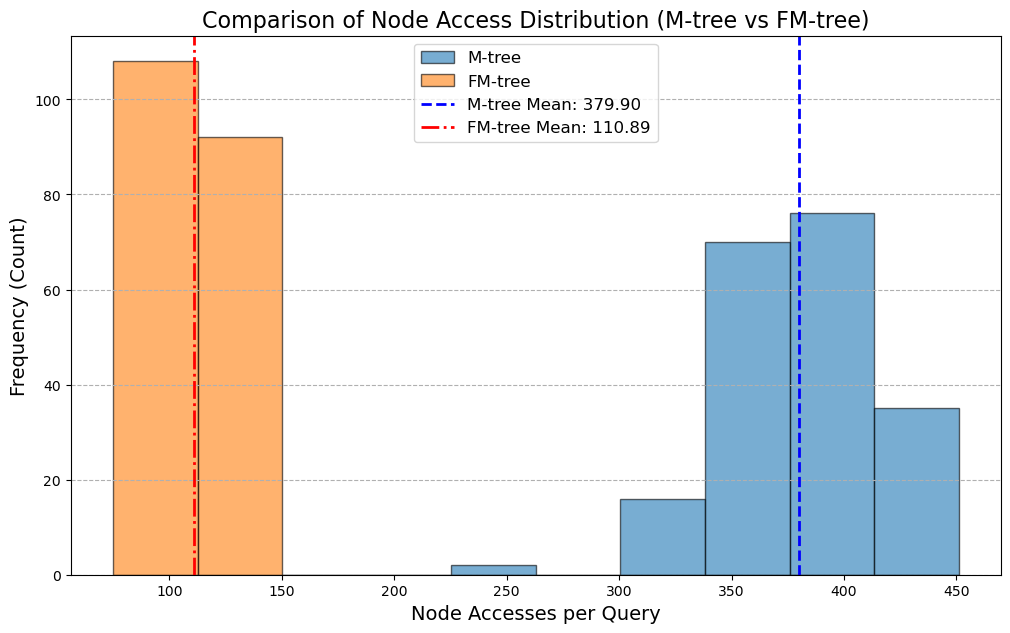

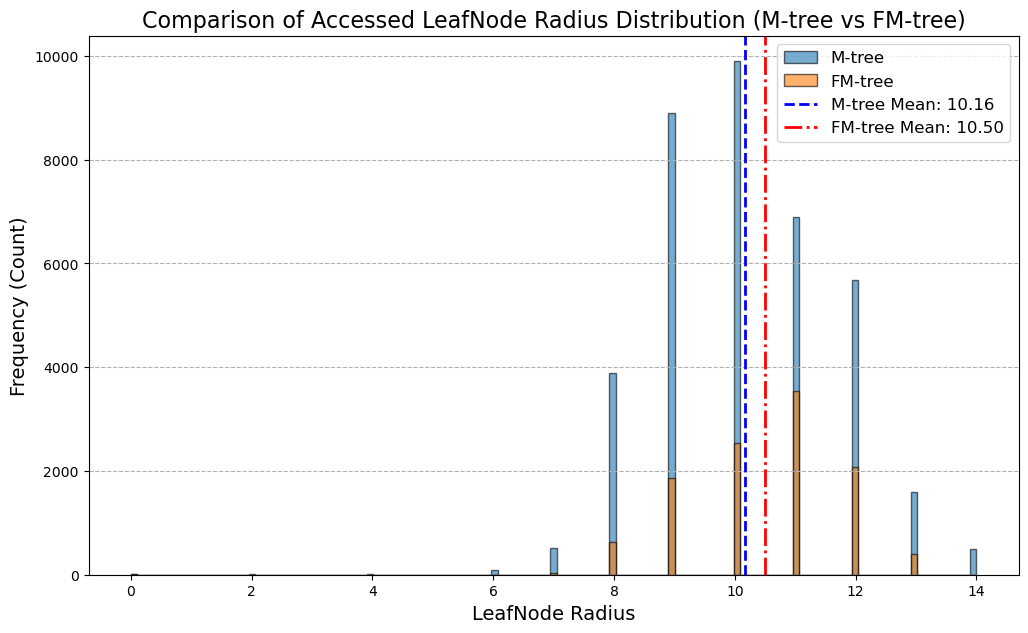

Script finished.


In [23]:
print("--- Generating Comparison Plots ---")
# --- 绘制 Node Access 对比图 ---
if mtree_accesses and fmtree_accesses:
    plot_comparison_histogram(
        mtree_accesses, 
        fmtree_accesses, 
        "Comparison of Node Access Distribution (M-tree vs FM-tree)", 
        "Node Accesses per Query", 
        "comparison_node_accesses.png"
    )

# --- 绘制 LeafNode Radius 对比图 ---
if mtree_radii and fmtree_radii:
    plot_comparison_histogram(
        mtree_radii, 
        fmtree_radii, 
        "Comparison of Accessed LeafNode Radius Distribution (M-tree vs FM-tree)", 
        "LeafNode Radius", 
        "comparison_leafnode_radii.png"
    )

# 显示所有图像
print("\nDisplaying plots...")
plt.show() # 在所有图都保存并绘制完成后，一次性显示

print("Script finished.")